In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from entsoe import EntsoePandasClient

In [25]:
API_TOKEN = "9af21e20-861e-41a0-873b-03c15cddf7c9"
client = EntsoePandasClient(api_key=API_TOKEN)

In [26]:
laender = {
    "Deutschland": "DE",
    "Frankreich":  "FR",
    "Spanien":     "ES",
    "Italien":     "IT",
    "Polen":       "PL",
    "Norwegen":    "NO",
    "Kroatien":    "HR"
}

start = pd.Timestamp("2023-01-01", tz="UTC")
end   = pd.Timestamp("2024-01-01", tz="UTC")

In [27]:
jahresdaten = {}

for land, kuerzel in laender.items():
    try:
        daten = client.query_load(kuerzel, start=start, end=end)
        gesamt = daten.sum()
        if hasattr(gesamt, 'item'):
            gesamt = gesamt.item()
        jahresdaten[land] = gesamt / 1_000_000
        print(f"{land}: {jahresdaten[land]:.2f} TWh")
    except Exception as e:
        print(f"{land}: Fehler – {e}")

Deutschland: 1833.53 TWh
Frankreich: 425.45 TWh
Spanien: 917.25 TWh
Italien: 276.14 TWh
Polen: 166.10 TWh
Norwegen: 134.49 TWh
Kroatien: 71.36 TWh


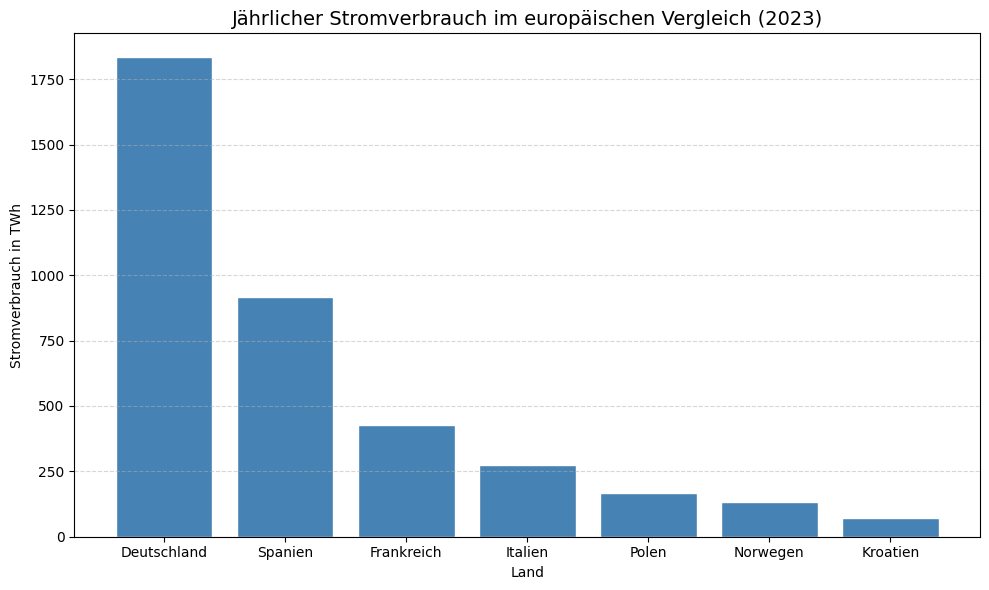

In [28]:
df = pd.DataFrame.from_dict(jahresdaten, orient="index", columns=["TWh"])
df = df.sort_values("TWh", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df.index, df["TWh"], color="steelblue", edgecolor="white")

ax.set_title("Jährlicher Stromverbrauch im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Land")
ax.set_ylabel("Stromverbrauch in TWh")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("lastvergleich_2023.png")
plt.show()

In [29]:
# Monatliche Daten pro Land abrufen
monatsdaten = {}

for land, kuerzel in laender.items():
    try:
        daten = client.query_load(kuerzel, start=start, end=end)
        # Auf Monate aggregieren - kompatibel mit allen pandas Versionen
        monatlich = daten.resample("MS").sum() / 1_000_000  # TWh
        if hasattr(monatlich, 'squeeze'):
            monatlich = monatlich.squeeze()
        monatsdaten[land] = monatlich
        print(f"{land}: Daten geladen ✅")
    except Exception as e:
        print(f"{land}: Fehler – {e}")

# Alle Länder in einen DataFrame zusammenführen
df_monate = pd.concat(monatsdaten, axis=1)
df_monate.columns = monatsdaten.keys()
df_monate = df_monate.sort_index()
df_monate = df_monate[df_monate.index.year == 2023]  # ← neu: nur Jahr 2023
df_monate.index = df_monate.index.strftime("%b")
df_monate = df_monate.round(2)
print(df_monate)

Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅
Spanien: Daten geladen ✅
Italien: Daten geladen ✅
Polen: Daten geladen ✅
Norwegen: Daten geladen ✅
Kroatien: Daten geladen ✅
     Deutschland  Frankreich  Spanien  Italien  Polen  Norwegen  Kroatien
Jan       152.55       40.67    77.37    22.63  13.97     11.97      5.96
Feb       163.51       39.29    77.56    23.44  14.89     13.40      6.02
Mar       144.62       33.87    66.22    20.68  13.20     10.82      5.52
Apr       145.29       30.46    69.77    21.58  12.92      9.70      5.43
May       141.90       30.02    74.71    22.57  12.62      8.63      5.57
Jun       145.01       31.29    84.98    26.96  13.05      8.55      6.66
Jul       145.23       29.93    80.88    22.85  13.27      9.03      6.42
Aug       143.25       30.55    73.34    23.28  13.12      8.99      5.64
Sep       155.18       32.22    73.96    23.06  14.14     11.62      5.51
Oct       164.36       38.14    75.07    22.58  14.64     13.34      5.88
Nov 

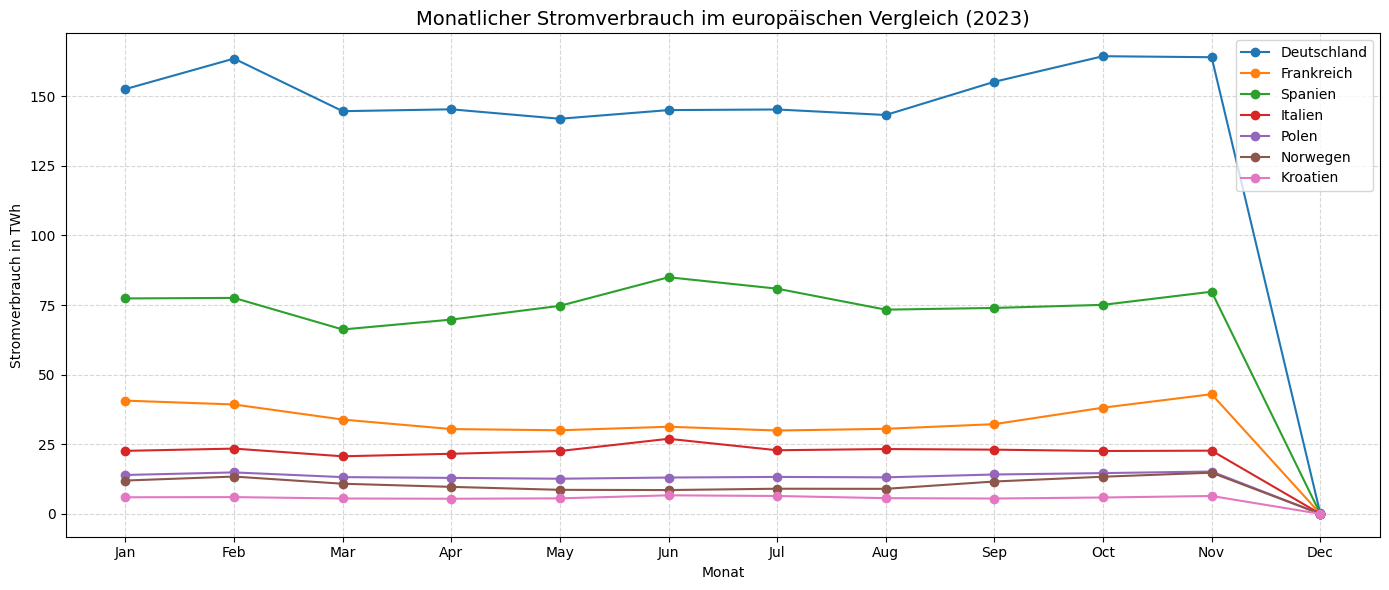

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

for land in df_monate.columns:
    ax.plot(df_monate.index, df_monate[land], marker="o", label=land)

ax.set_title("Monatlicher Stromverbrauch im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Monat")
ax.set_ylabel("Stromverbrauch in TWh")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("lastgang_linien_2023.png")
plt.show()

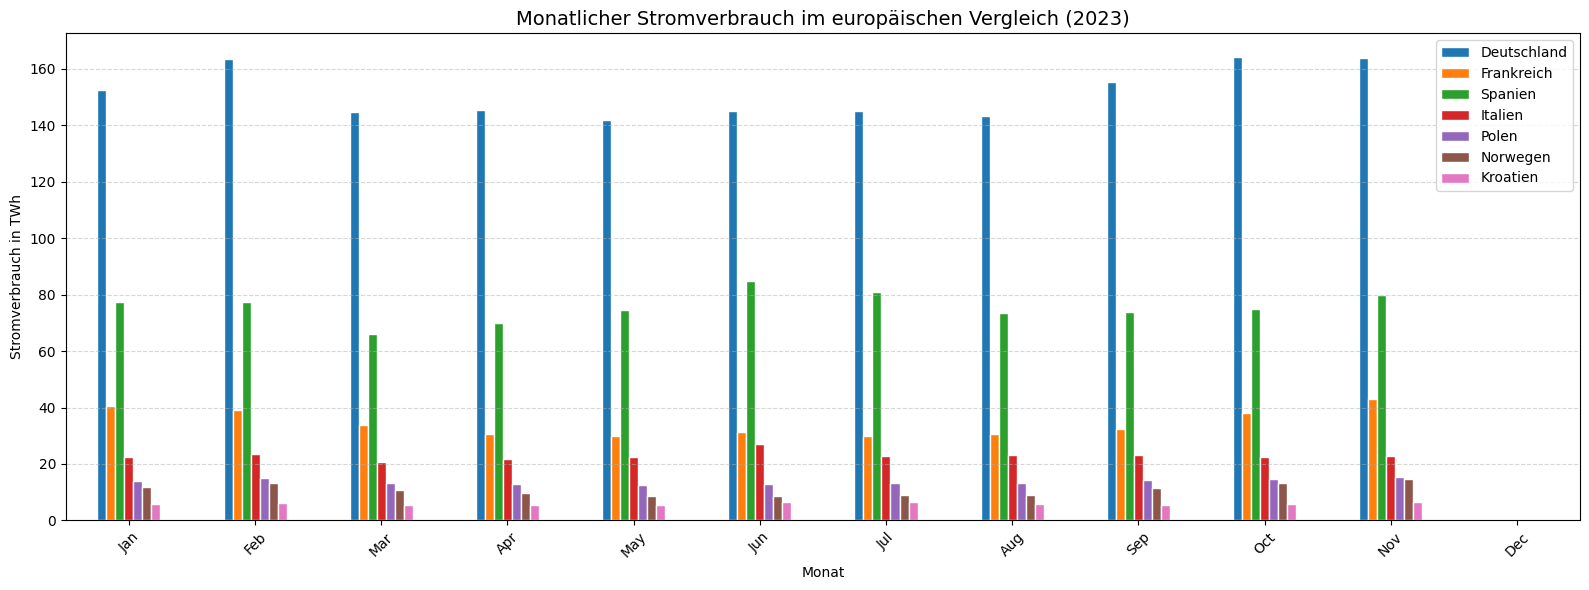

In [31]:
fig, ax = plt.subplots(figsize=(16, 6))

df_monate.plot(kind="bar", ax=ax, edgecolor="white")

ax.set_title("Monatlicher Stromverbrauch im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Monat")
ax.set_ylabel("Stromverbrauch in TWh")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lastgang_balken_2023.png")
plt.show()